# Final project:Disaster Tweet Classification
## Rustemkyzy Akniyet

## **Part 1 — Libraries**

In [155]:
import pandas as pd # работа с таблицами и csv
import re # очистка текста (ссылки, символы и тд)
import os # создание папок и сохранение файлов

import matplotlib.pyplot as plt # графики

# делю данные на train / validation / test
from sklearn.model_selection import train_test_split

# превращаю текст в числа через важность слов
from sklearn.feature_extraction.text import TfidfVectorizer

# baseline модель для сравнения
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, # сколько всего правильно угадала
    precision_score, # если сказала disaster, насколько права
    recall_score, # сколько настоящих disaster нашла
    f1_score, # баланс precision и recall
    confusion_matrix, # матрица ошибок
    classification_report, # все метрики сразу
    ConfusionMatrixDisplay # красивая визуализация матрицы

)

import torch # библиотека deep learning
import torch.nn as nn # слои: LSTM, Linear, Embedding и тд


# Dataset хранит данные \ DataLoader делит данные по batch
from torch.utils.data import Dataset, DataLoader


# считает слова для словаря
from collections import Counter

## **Part 2 — Load Dataset**

In [156]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

print(train_df.head())
print(train_df.columns)

Train shape: (7613, 5)
Test shape: (3263, 4)
Sample submission shape: (3263, 2)
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')


## **Part 3 — Data Inspection**

In [157]:
print("Missing values in train:")
print(train_df.isnull().sum())

print("Missing values in test:")
print(test_df.isnull().sum())

print("Class balance:")
print(train_df["target"].value_counts())

print("Class balance percentage:")
print(train_df["target"].value_counts(normalize=True))

Missing values in train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64
Missing values in test:
id             0
keyword       26
location    1105
text           0
dtype: int64
Class balance:
target
0    4342
1    3271
Name: count, dtype: int64
Class balance percentage:
target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


## **Part 4 — Text Cleaning**

In [158]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Original text:")
print(train_df["text"].iloc[0])

print("Cleaned text:")
print(train_df["clean_text"].iloc[0])

Original text:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned text:
our deeds are the reason of this earthquake may allah forgive us all


## **Part 5 — Train / Validation / Test Split**

In [159]:
X = train_df["clean_text"]
y = train_df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 5329
Validation: 1142
Test: 1142


## **Part 6 — Baseline: TF-IDF + Logistic Regression**

In [160]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

val_pred = baseline_model.predict(X_val_tfidf)
test_pred = baseline_model.predict(X_test_tfidf)

## **Part 7 — Baseline Evaluation**

In [161]:
print("Validation Results")
print("Accuracy:", round(accuracy_score(y_val, val_pred), 4))
print("Precision:", round(precision_score(y_val, val_pred), 4))
print("Recall:", round(recall_score(y_val, val_pred), 4))
print("F1-score:", round(f1_score(y_val, val_pred), 4))
print(classification_report(y_val, val_pred))
print(confusion_matrix(y_val, val_pred))

print("Test Results")
print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall:", round(recall_score(y_test, test_pred), 4))
print("F1-score:", round(f1_score(y_test, test_pred), 4))
print(classification_report(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Validation Results
Accuracy: 0.7995
Precision: 0.8149
Recall: 0.6904
F1-score: 0.7475
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       651
           1       0.81      0.69      0.75       491

    accuracy                           0.80      1142
   macro avg       0.80      0.79      0.79      1142
weighted avg       0.80      0.80      0.80      1142

[[574  77]
 [152 339]]
Test Results
Accuracy: 0.817
Precision: 0.8386
Recall: 0.7102
F1-score: 0.7691
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       652
           1       0.84      0.71      0.77       490

    accuracy                           0.82      1142
   macro avg       0.82      0.80      0.81      1142
weighted avg       0.82      0.82      0.81      1142

[[585  67]
 [142 348]]


## **Part 8 — Prepare Text for LSTM / GRU**

In [162]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def tokenize(text):
    return str(text).split()


counter = Counter()

for text in X_train:
    counter.update(tokenize(text))


max_vocab_size = 10000

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.most_common(max_vocab_size - 2):
    word2idx[word] = len(word2idx)

print("Vocabulary size:", len(word2idx))

Device: cpu
Vocabulary size: 10000


## **Part 9 — Encode and Pad Text**

In [163]:
max_len = 40


def encode_text(text):
    tokens = tokenize(text)
    ids = []

    for token in tokens:
        ids.append(word2idx.get(token, word2idx["<UNK>"]))

    if len(ids) < max_len:
        ids = ids + [word2idx["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids


X_train_ids = [encode_text(text) for text in X_train]
X_val_ids = [encode_text(text) for text in X_val]
X_test_ids = [encode_text(text) for text in X_test]

print(X_train_ids[0])
print(len(X_train_ids[0]))

[2595, 2099, 4, 181, 1784, 10, 2100, 767, 412, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
40


## **Part 10 — Dataset and DataLoader**

In [164]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]


train_dataset = TweetDataset(X_train_ids, y_train)
val_dataset = TweetDataset(X_val_ids, y_val)
test_dataset = TweetDataset(X_test_ids, y_test)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 167
Validation batches: 36
Test batches: 36


## **Part 11 — LSTM Model**

In [165]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        last_hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden)

        return logits

## **Part 12 — GRU Model**

In [166]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x):
        embedded = self.embedding(x)

        output, hidden = self.gru(embedded)

        last_hidden = hidden[-1]

        logits = self.fc(last_hidden)

        return logits

## **Part 13 — Training Function**

In [167]:
def train_model(model, train_loader, val_loader, epochs=5):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):
        model.train()

        train_loss = 0

        for texts, labels in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(texts)

            loss = criterion(logits, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for texts, labels in val_loader:
                texts = texts.to(device)
                labels = labels.to(device)

                logits = model(texts)

                loss = criterion(logits, labels)

                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

    return model

## **Part 14 — Evaluation Function**

In [168]:
def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts)

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))

    print(classification_report(all_labels, all_preds))
    print(confusion_matrix(all_labels, all_preds))

    return acc, prec, rec, f1, all_preds

## **Part 15 — Train and Evaluate LSTM**

In [169]:
lstm_model = LSTMClassifier(
    vocab_size=len(word2idx),
    embedding_dim=64,
    hidden_dim=64,
    output_dim=2
)

print(lstm_model)

lstm_model = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=5
)

print("LSTM Test Results:")

lstm_accuracy, lstm_precision, lstm_recall, lstm_f1, lstm_preds = evaluate_model(
    lstm_model,
    test_loader
)

LSTMClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Epoch 1/5 | Train Loss: 0.6341 | Val Loss: 0.5651 | Val Accuracy: 0.7128
Epoch 2/5 | Train Loss: 0.5118 | Val Loss: 0.5339 | Val Accuracy: 0.7356
Epoch 3/5 | Train Loss: 0.4277 | Val Loss: 0.5290 | Val Accuracy: 0.7443
Epoch 4/5 | Train Loss: 0.3555 | Val Loss: 0.5433 | Val Accuracy: 0.7583
Epoch 5/5 | Train Loss: 0.2829 | Val Loss: 0.5699 | Val Accuracy: 0.7539
LSTM Test Results:
Accuracy: 0.7828
Precision: 0.7738
Recall: 0.698
F1-score: 0.7339
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       652
           1       0.77      0.70      0.73       490

    accuracy                           0.78      1142
   macro avg       0.78      0.77      0.78      1142
weighted avg       0.78      0.78      0.78   

## **Part 16 — Train and Evaluate GRU**

In [170]:
gru_model = GRUClassifier(
    vocab_size=len(word2idx),
    embedding_dim=64,
    hidden_dim=64,
    output_dim=2
)

print(gru_model)

gru_model = train_model(
    gru_model,
    train_loader,
    val_loader,
    epochs=5
)

print("GRU Test Results:")

gru_accuracy, gru_precision, gru_recall, gru_f1, gru_preds = evaluate_model(
    gru_model,
    test_loader
)

GRUClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Epoch 1/5 | Train Loss: 0.6856 | Val Loss: 0.6847 | Val Accuracy: 0.5701
Epoch 2/5 | Train Loss: 0.6792 | Val Loss: 0.6497 | Val Accuracy: 0.5701
Epoch 3/5 | Train Loss: 0.6000 | Val Loss: 0.5834 | Val Accuracy: 0.6996
Epoch 4/5 | Train Loss: 0.4853 | Val Loss: 0.5641 | Val Accuracy: 0.7356
Epoch 5/5 | Train Loss: 0.3991 | Val Loss: 0.5727 | Val Accuracy: 0.7329
GRU Test Results:
Accuracy: 0.7592
Precision: 0.7096
Recall: 0.7429
F1-score: 0.7258
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       652
           1       0.71      0.74      0.73       490

    accuracy                           0.76      1142
   macro avg       0.75      0.76      0.76      1142
weighted avg       0.76      0.76      0.76      1142

[[503 149]
 [126 364]]


## **Part 17 — Model Comparison**

In [171]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression TF-IDF",
        "LSTM",
        "GRU"
    ],
    "Accuracy": [
        accuracy_score(y_test, test_pred),
        lstm_accuracy,
        gru_accuracy
    ],
    "Precision": [
        precision_score(y_test, test_pred),
        lstm_precision,
        gru_precision
    ],
    "Recall": [
        recall_score(y_test, test_pred),
        lstm_recall,
        gru_recall
    ],
    "F1": [
        f1_score(y_test, test_pred),
        lstm_f1,
        gru_f1
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression TF-IDF,0.816988,0.838554,0.710204,0.769061
1,LSTM,0.782837,0.773756,0.697959,0.733906
2,GRU,0.759194,0.709552,0.742857,0.725823


## **Part 18 — Save Results**

In [172]:
os.makedirs("results", exist_ok=True)

results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

print("Saved: results/model_comparison.csv")

Saved: results/model_comparison.csv


## **Part 19 — Plots**

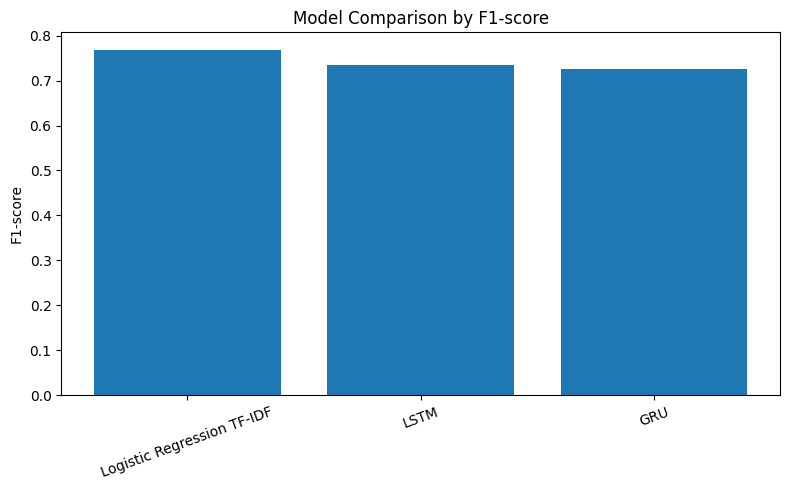

In [173]:
# Plot 1: Model comparison by F1-score

# создаю папку results если ее нет
os.makedirs("results", exist_ok=True)

# создаю график
plt.figure(figsize=(8, 5))

# строю bar plot по F1-score
plt.bar(
    results_df["Model"],
    results_df["F1"]
)

# название графика
plt.title("Model Comparison by F1-score")

# подпись оси Y
plt.ylabel("F1-score")

# поворачиваю названия моделей
plt.xticks(rotation=20)

# чтобы текст не обрезался
plt.tight_layout()

# сохраняю график в папку results
plt.savefig("results/model_comparison_f1.png", dpi=300)

# показываю график
plt.show()

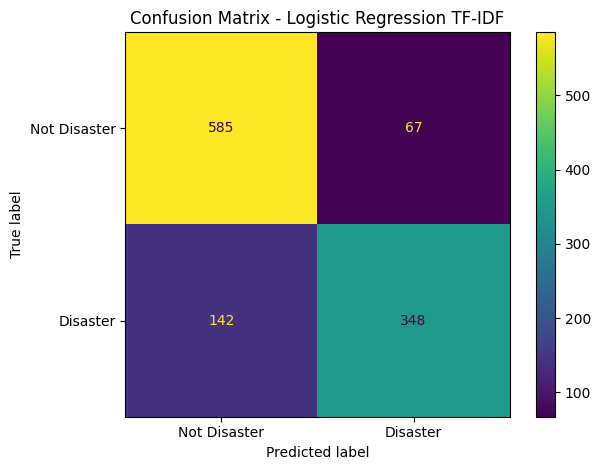

In [174]:
# Plot 2: Confusion Matrix for Best Model

# считаю confusion matrix
cm = confusion_matrix(y_test, test_pred)

# создаю display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster", "Disaster"]
)

# рисую матрицу
disp.plot()

# название
plt.title("Confusion Matrix - Logistic Regression TF-IDF")

# чтобы не обрезалось
plt.tight_layout()

# сохраняю картинку
plt.savefig("results/confusion_matrix_logistic_regression.png", dpi=300)

# показываю
plt.show()


## **Error Analysis**

In [175]:
lr_errors = []

for text, true_label, pred_label in zip(X_test, y_test, test_pred):
    if true_label != pred_label:
        lr_errors.append({
            "text": text,
            "true_label": true_label,
            "predicted_label": pred_label
        })

lr_errors_df = pd.DataFrame(lr_errors)

lr_errors_df.head(10)

,text,true_label,predicted_label
0,on the flip side im at walmart and there is a ...,1,0
1,tube strike live latest travel updates as lond...,1,0
2,spot flood combo inch w curved cree led work l...,1,0
3,unpredictable disconnected and social casualty...,1,0
4,auction shoes retro fire red,0,1
5,zayn malik amp perrie edwards end engagement s...,1,0
6,was in nyc last week,0,1
7,hollywood movie about trapped miners released ...,1,0
8,russia may have played into reason but that li...,1,0
9,growth dries up for bhp billiton as oil price ...,0,1


In [176]:
os.makedirs("results", exist_ok=True)

lr_errors_df.to_csv(
    "results/best_model_error_analysis.csv",
    index=False
)

print("Saved: results/best_model_error_analysis.csv")

Saved: results/best_model_error_analysis.csv
